| Step | Action                                                                 | Output                                     |
| ---- | ---------------------------------------------------------------------- | ------------------------------------------ |
| 1    | Select a small sample from each predefined training and test set       | Original reviews and matching `pos` labels |
| 2    | Load the BERT tokenizer and pretrained model                           | `tokenizer`, `model`                       |
| 3    | Tokenize, pad, and create attention masks in batches                   | BERT inputs                                |
| 4    | Generate embeddings and extract the `[CLS]` vectors                    | `X_train_embeddings`, `X_test_embeddings`  |
| 5    | Train Logistic Regression on training embeddings and labels            | `model_bert_lr`                            |
| 6    | Predict on test embeddings and calculate accuracy and F1               | Test results                               |
| 7    | Apply the same BERT processing to your eight reviews and classify them | Sentiment predictions                      |


In [1]:
import pandas as pd
import numpy as np
import torch
import transformers 
import re

In [2]:
# Load only the first 100 rows
df = pd.read_csv('/home/susan/Natural_Language_Processing/data/imdb_reviews.tsv', sep ='\t', nrows=100)

In [3]:
# 1. Select the needed columns
df_text = df[['review', 'pos', 'ds_part']].copy()

# check the data 
print(df_text.shape)
# check missing and duplicated data
print("missing_data:\n",df_text.isna().sum())
print("duplicated_data:\n",df_text.duplicated(subset=['review']).sum())
print(df_text['pos'].value_counts())
print(df_text['ds_part'].value_counts())

(100, 3)
missing_data:
 review     0
pos        0
ds_part    0
dtype: int64
duplicated_data:
 0
pos
0    52
1    48
Name: count, dtype: int64
ds_part
train    64
test     36
Name: count, dtype: int64


In [4]:
# lowercase the reviews and normalize extra whitespace.
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Replace repeated whitespace with one space
    text = re.sub(r'\s+', ' ', text)

    # Remove spaces at the beginning and end
    text = text.strip()

    return text

clean_reviews = []

for review in df_text['review']:
    cleaned_review = preprocess_text(review)
    clean_reviews.append(cleaned_review)
    
df_text['review_clean'] = clean_reviews
print(df_text.columns)

print(df_text.shape)

Index(['review', 'pos', 'ds_part', 'review_clean'], dtype='str')
(100, 4)


pos
0    52.0
1    48.0
Name: proportion, dtype: float64


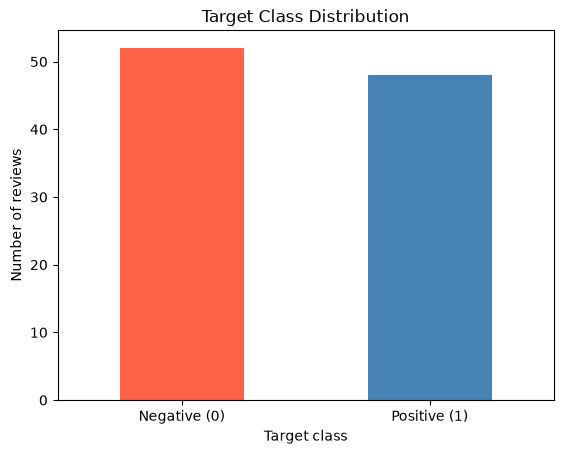

In [5]:
# Display up to five rows with duplicate cleaned reviews
duplicates = df_text.duplicated(subset=["review_clean"], keep="first")
# Remove duplicate cleaned reviews and keep the first occurrence
df_text = df_text.drop_duplicates(
    subset=['review_clean'],
    keep='first'
).copy()
df_text.duplicated(subset=['review_clean']).sum()
# preprocess for modeling:
# Examine the traget distribution 
# Count  class percentatage
class_counts =class_percentages = (
    df_text['pos']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100))
print(class_percentages)

# visualization the distribution
import matplotlib.pyplot as plt

class_counts.plot(
    kind='bar',
    color=['tomato', 'steelblue']
)

plt.title('Target Class Distribution')
plt.xlabel('Target class')
plt.ylabel('Number of reviews')
plt.xticks(
    ticks=[0, 1],
    labels=['Negative (0)', 'Positive (1)'],
    rotation=0
)
plt.show()

Hugging Face recommends using AutoTokenizer and AutoModel. This makes it incredibly easy to swap BERT out for other models (like RoBERTa or DistilBERT) later without changing your architecture code:

In [6]:
 
from transformers import AutoTokenizer, AutoModel

# Automatically detects and loads BERT configurations
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:


# Step 2: Tokenize, pad, and create attention masks in batches
inputs = tokenizer(
    df_text['review_clean'].tolist(),
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors='pt') # Returns PyTorch Tensors
print(inputs.keys())
print(inputs["input_ids"].shape)
print(inputs["attention_mask"].shape)

KeysView({'input_ids': tensor([[  101,  1996, 22190,  ...,     0,     0,     0],
        [  101,  2129,  1996,  ...,     0,     0,     0],
        [  101,  2045,  2003,  ...,     0,     0,     0],
        ...,
        [  101,  1045,  2428,  ...,     0,     0,     0],
        [  101,  1045,  5632,  ...,     0,     0,     0],
        [  101,  1999,  2727,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})
torch.Size([100, 512])
torch.Size([100, 512])


In [8]:
# Generate BERT [CLS] embeddings in batches
# Select GPU if available; otherwise, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move BERT to the selected device
model = model.to(device)

# Put BERT in evaluation mode
model.eval()
# Generate [CLS] embeddings from already-tokenized inputs
def get_cls_embeddings(inputs, batch_size=16):

    # Store the embeddings from each batch
    embeddings = []

    # Find the total number of reviews
    number_of_reviews = inputs["input_ids"].shape[0]

    # Disable gradient calculations
    with torch.inference_mode():

        # Process the tokenized reviews in batches
        for start in range(0, number_of_reviews, batch_size):

            end = start + batch_size

            # Select the current batch from every input tensor
            # and move it to the same device as BERT
            batch_inputs = {
                key: value[start:end].to(device)
                for key, value in inputs.items()
            }

            # Pass the current batch through BERT
            outputs = model(**batch_inputs)

            # Extract the [CLS] vector from every review
            cls_vectors = outputs.last_hidden_state[:, 0, :]

            # Move embeddings to CPU and convert them to NumPy
            embeddings.append(cls_vectors.cpu().numpy())

    # Combine embeddings from all batches
    return np.vstack(embeddings)

In [9]:
all_embeddings = get_cls_embeddings(
    inputs,
    batch_size=16
)

print(all_embeddings.shape)

(100, 768)


In [11]:
# Create Boolean masks for the predefined train and test rows
train_mask = df_text["ds_part"].eq("train").to_numpy()
test_mask = df_text["ds_part"].eq("test").to_numpy()

# Separate the BERT embeddings
X_train_embeddings = all_embeddings[train_mask]
X_test_embeddings = all_embeddings[test_mask]

# Separate the matching labels
y_train = df_text.loc[train_mask, "pos"].to_numpy()
y_test = df_text.loc[test_mask, "pos"].to_numpy()

# Checking the result :
print("X_train_embeddings:", X_train_embeddings.shape)
print("y_train:", y_train.shape)

print("X_test_embeddings:", X_test_embeddings.shape)
print("y_test:", y_test.shape)

X_train_embeddings: (64, 768)
y_train: (64,)
X_test_embeddings: (36, 768)
y_test: (36,)


In [12]:
print("Training labels:")
print(pd.Series(y_train).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())

Training labels:
1    33
0    31
Name: count, dtype: int64

Test labels:
0    21
1    15
Name: count, dtype: int64


In [13]:
from sklearn.linear_model import LogisticRegression

# Train the classifier using BERT embeddings
model_bert_lr = LogisticRegression(
    max_iter=1000,
    random_state=12345
)

model_bert_lr.fit(X_train_embeddings, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",12345
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [14]:
from sklearn.metrics import accuracy_score, f1_score

# Predict the test-review labels
y_test_pred = model_bert_lr.predict(X_test_embeddings)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Test accuracy:", accuracy)
print("Test F1 score:", f1)

Test accuracy: 0.8055555555555556
Test F1 score: 0.7407407407407407
